# Seleção e ajuste de modelos

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Em muitos métodos de classificação e regressão, precisamos definir os valores dos hiperparâmetros dos modelos, que são parâmetros ajustados pelo usuário (não aprendidos diretamente dos dados). Exemplos desses métodos são o algoritmo k-vizinhos, onde precisamos definir o valor k, e o número de árvores no algoritmo florestas aleatórias. No caso de regressão, o desafio é identificar as variáveis significativas.

### Classificação

Se dividirmos o conjunto de dados em apenas duas partes, uma de teste e outra de treinamento — método chamado **holdout** —, dependendo da execução do classificador podemos obter resultados diferentes. A seguir, mostramos o desempenho do classificador GaussianNB de acordo com a execução. Notem que os valores se distribuem de acordo com uma distribuição de probabilidade que se aproxima de uma Gaussiana.

In [43]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
random.seed(42) # define the seed (important to reproduce the results)

data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/winequality-red.csv', header=(0))
#data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  
# nomes dos atributos
features = data.columns
features = features[0:-1]

nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)
data.head(10)

Matriz de atributos: Número de linhas: 310  colunas:  7


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
5,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia
7,45.366754,10.755611,29.038349,34.611142,117.270067,-10.675871,Hernia
8,43.790190,13.533753,42.690814,30.256437,125.002893,13.289018,Hernia
9,36.686353,5.010884,41.948751,31.675469,84.241415,0.664437,Hernia


In [44]:
import numpy as np

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:, 0:-1].astype(float)

Acurácia média: 0.8253763440860216  desvio padrão: 0.030035243490664963


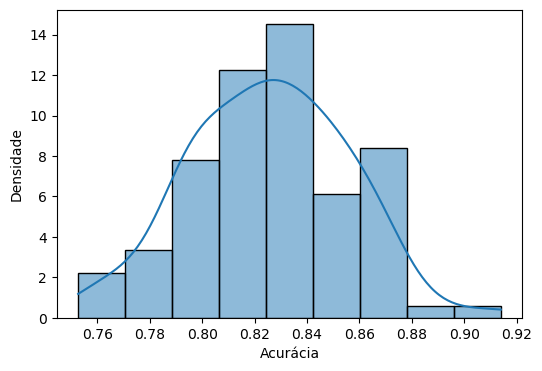

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import seaborn as sns

p = 0.7   # fração de elementos no conjunto de treinamento
Ns = 100  # número de execuções da classificação (sem fixar random_state,
          # de propósito, para evidenciar a variabilidade do holdout)
vacc = []
for n in range(Ns):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=p)

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    vacc.append(accuracy_score(y_pred, y_test))

print('Acurácia média:', np.mean(vacc), ' desvio padrão:', np.std(vacc))

plt.figure(figsize=(6, 4))
sns.histplot(vacc, kde=True, stat="density")
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.xlabel('Acurácia', fontsize=10)
plt.ylabel('Densidade', fontsize=10)
plt.show()

Portanto, podemos ter uma alta ou baixa acurácia, dependendo da execução.

Além disso, a escolha dos hiperparâmetros do modelo também é influenciada pela execução. Vamos considerar um exemplo: no classificador k-vizinhos, o hiperparâmetro k influencia a classificação, e a escolha do melhor valor de k pode depender da execução, se usarmos o método hold-out, conforme vemos a seguir.

Execução: 0  - Melhor k: 21
Execução: 1  - Melhor k: 1
Execução: 2  - Melhor k: 7
Execução: 3  - Melhor k: 10
Execução: 4  - Melhor k: 5


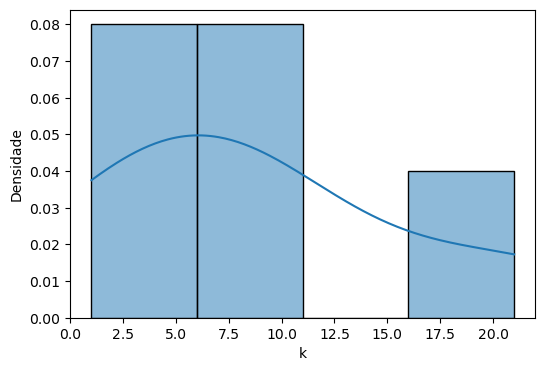

In [46]:
from sklearn.neighbors import KNeighborsClassifier

p = 0.7  # fração de elementos no conjunto de treinamento
Ns = 5   # número de execuções da classificação
vk = []  # armazena o melhor k
# executa a classificação Ns vezes
for n in range(Ns):
    # separa os conjuntos de treinamento e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=p)
    # varia o k na classificação
    vbest = []
    for k in range(1, 30):
        model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        vbest.append(accuracy_score(y_pred, y_test))
    # guarda o melhor k
    kbest = np.argmax(vbest) + 1
    vk.append(kbest)
    print('Execução:', n, ' - Melhor k:', kbest)

plt.figure(figsize=(6, 4))
sns.histplot(vk, kde=True, stat="density")
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.xlabel('k', fontsize=10)
plt.ylabel('Densidade', fontsize=10)
plt.show()

Portanto, dependendo da execução, podemos encontrar um valor diferente para k, de modo a obter a melhor acurácia. Logo, não podemos escolher o melhor modelo de maneira confiável usando apenas um único holdout.

### Validação cruzada

Para evitarmos essa dependência da execução e diminuirmos a variância, podemos usar os métodos de **validação cruzada**.

<img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" width="500">

In [47]:
from sklearn.model_selection import KFold

# Define uma validação cruzada com 10 partições (10-fold cross-validation).
# A base será dividida em 10 subconjuntos de tamanhos semelhantes.
# Em cada iteração:
#   - 9 subconjuntos serão usados para treinamento;
#   - 1 subconjunto será usado para teste.
cv = KFold(n_splits=10)

# Lista que armazenará a acurácia obtida em cada uma das 10 execuções.
vacc = []

# Percorre todas as partições geradas pelo KFold.
for train_index, test_index in cv.split(X, y):
    # Seleciona os exemplos de treinamento.
    x_train = X[train_index]
    y_train = y[train_index]
    # Seleciona os exemplos de teste.
    x_test = X[test_index]
    y_test = y[test_index]
    # Cria um classificador Naive Bayes Gaussiano.
    model = GaussianNB()
    # Ajusta (treina) o modelo utilizando apenas os dados de treinamento.
    model.fit(x_train, y_train)
    # Prediz as classes dos exemplos do conjunto de teste.
    y_pred = model.predict(x_test)
    # Calcula a acurácia desta partição.
    acc = accuracy_score(y_test, y_pred)
    # Armazena o resultado.
    vacc.append(acc)

# Mostra a acurácia obtida em cada uma das 10 partições.
print("Acurácia em cada fold:")
print(np.round(vacc, 4))

# Calcula a média das acurácias.
print("\nAcurácia média:", np.mean(vacc))

# Calcula o desvio padrão das acurácias.
# Um desvio pequeno indica que o modelo apresenta desempenho
# consistente entre as diferentes partições.
print("Desvio padrão:", np.std(vacc))

Acurácia em cada fold:
[0.3871 0.6452 0.9355 0.9355 1.     1.     0.9355 0.6129 0.6129 0.5806]

Acurácia média: 0.7645161290322581
Desvio padrão: 0.20858275045583496


Notem que, mesmo que executemos o código várias vezes, obtemos sempre aproximadamente a mesma acurácia.

In [48]:
for i in range(5):
    cv = KFold(n_splits=10, shuffle=True)
    vacc = []
    for train_index, test_index in cv.split(X, y):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        model = GaussianNB()
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        vacc.append(accuracy_score(y_pred, y_test))
    print('Acurácia média:', np.mean(vacc))

Acurácia média: 0.8161290322580644
Acurácia média: 0.8258064516129032
Acurácia média: 0.8096774193548386
Acurácia média: 0.8193548387096774
Acurácia média: 0.8225806451612903


Caso os dados sejam desbalanceados, podemos usar ainda a validação cruzada estratificada, que preserva a proporção de cada classe em cada partição (fold).

In [49]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

vacc = []
for train_index, test_index in cv.split(X, y):
    x_train, x_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = GaussianNB()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    vacc.append(accuracy_score(y_pred, y_test))

print('Acurácia média:', np.mean(vacc))

Acurácia média: 0.8258064516129032


Para escolhermos os melhores hiperparâmetros do modelo usando validação cruzada, podemos usar o método `GridSearchCV` da biblioteca scikit-learn. O GridSearchCV procura automaticamente a melhor combinação de hiperparâmetros de um modelo usando validação cruzada.

Em vez de testar manualmente vários valores, ele faz isso automaticamente.

O GridSearchCV executa os seguintes passos:
- define uma grade (grid) de hiperparâmetros;
- testa todas as combinações possíveis;
- avalia cada combinação usando validação cruzada;
- calcula a média da métrica escolhida (por exemplo, acurácia);
- seleciona automaticamente a combinação com o melhor desempenho;
- disponibiliza o melhor modelo treinado por meio de `best_estimator_`.

Ele é uma das ferramentas mais utilizadas para seleção automática de hiperparâmetros em aprendizado de máquina.

Por exemplo, em um árvore:
* `parametros = {'max_depth': [3,5,7],'criterion': ['gini','entropy']}`

Serão testados:
- 3, gini
- 5, gini
- 7, gini
- 3, entropy
- 5, entropy
- 7, entropy

In [50]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': list(range(1, 11))}
model = KNeighborsClassifier(metric='euclidean')
best_model = GridSearchCV(model, parameters, cv=10)
best_model.fit(X, y)
y_pred = best_model.predict(X)

print('Melhores hiperparâmetros:', best_model.best_params_)
print('Acurácia média na validação cruzada (best_score_):', best_model.best_score_)
print('Acurácia sobre X (mesmos dados usados no ajuste):', accuracy_score(y_pred, y))

Melhores hiperparâmetros: {'n_neighbors': 10}
Acurácia média na validação cruzada (best_score_): 0.8483870967741935
Acurácia sobre X (mesmos dados usados no ajuste): 0.8838709677419355


Repare que a última linha impressa acima (acurácia sobre `X`) tende a ser mais otimista do que `best_score_`: ela é calculada prevendo sobre os **mesmos dados** que já foram usados para treinar o modelo final, então não é uma estimativa confiável do desempenho em dados novos. 

Por outro lado, `best_score_` é a média das acurácias nos folds de validação cruzada, sendo a estimativa correta a ser reportada. Ainda assim, note que nem `best_score_` avalia o modelo em dados totalmente independentes do processo de seleção de hiperparâmetros: para isso, precisaríamos de um conjunto de teste separado desde o início, como discutido a seguir.

Essa mesma execução pode ser obtida com o código abaixo, testando manualmente cada valor de k e usando `cross_validate`. Isso ilustra o que o `GridSearchCV` faz internamente — na prática, é preferível usar o `GridSearchCV`, que automatiza esse processo.

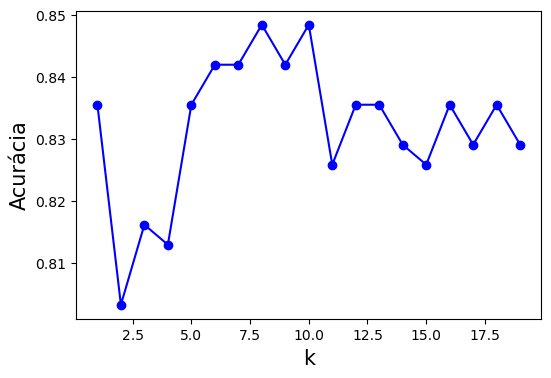

Melhor k: 10
Acurácia sobre X (mesmos dados usados no ajuste): 0.8838709677419355


In [51]:
from sklearn.model_selection import cross_validate

nkf = 10  # número de folds
vk = []
vscore = []
for k in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    # realiza a validação cruzada
    cv = cross_validate(model, X, y, cv=nkf)
    vscore.append(cv['test_score'].mean())
    vk.append(k)

plt.figure(figsize=(6, 4))
plt.plot(vk, vscore, '-bo')
plt.xlabel('k', fontsize=15)
plt.ylabel('Acurácia', fontsize=15)
plt.show()

best_k = np.argmax(vscore) + 1
print('Melhor k:', best_k)
best_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
best_model.fit(X, y)
y_pred = best_model.predict(X)
print('Acurácia sobre X (mesmos dados usados no ajuste):', accuracy_score(y_pred, y))

Quando `cv` é passado como um número inteiro (como `cv=10` acima) e o estimador é um classificador, o scikit-learn já usa `StratifiedKFold` internamente por padrão, não sendo necessário construir esse objeto manualmente nesse caso.

## Seleção do modelo usando grid_search

Ver: https://scikit-learn.org/stable/modules/grid_search.html

Vamos ler os dados novamente.

In [52]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
random.seed(42) # define the seed (important to reproduce the results)

data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/winequality-red.csv', header=(0))
#data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  
# nomes dos atributos
features = data.columns
features = features[0:-1]

nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:, 0:-1].astype(float)

Matriz de atributos: Número de linhas: 310  colunas:  7


É possível escolher os hiperparâmetros de um modelo usando o método `GridSearchCV` da biblioteca scikit-learn. Vamos inicialmente ler os dados e separar os conjuntos de treinamento e teste — desta vez, usando o conjunto de dados **Iris**.

Notem que usamos `stratify=y` no `train_test_split` para manter a proporção de cada classe nos conjuntos de treino e teste.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=4, stratify=y)

Para realizar o grid search, precisamos definir quais hiperparâmetros serão considerados e os valores que serão testados.

In [54]:
grid_params = {
    'n_neighbors': [5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan'],
}

Podemos então chamar o método. Note que já fazemos a validação cruzada (`cv=3`) para avaliar cada combinação de hiperparâmetros.

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

gs = GridSearchCV(KNeighborsClassifier(), grid_params, verbose=1, cv=3, n_jobs=-1)

Aplicamos aos dados de treinamento.

In [59]:
g_res = gs.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


A acurácia média obtida na validação cruzada, para a melhor combinação de hiperparâmetros:

In [60]:
print("Acurácia (validação cruzada):", g_res.best_score_)

Acurácia (validação cruzada): 0.8440860215053764


Os melhores hiperparâmetros identificados para obter essa acurácia:

In [61]:
print("Melhores hiperparâmetros:", g_res.best_params_)

Melhores hiperparâmetros: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}


Finalmente, ajustamos o modelo final com os melhores hiperparâmetros encontrados.

In [62]:
# Usa diretamente os melhores hiperparâmetros encontrados pelo grid search
knn = KNeighborsClassifier(**g_res.best_params_)
knn.fit(X_train, y_train)

# Alternativa equivalente, também válida:
# knn = g_res.best_estimator_

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['Hernia','Normal','Spondylolisthesis']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'ma...an'


Fazemos a predição e calculamos a acurácia com esses melhores hiperparâmetros, tanto no conjunto de treinamento quanto no de teste.

In [63]:
y_hat = knn.predict(X_train)
y_knn = knn.predict(X_test)

print('Acurácia no treinamento:', accuracy_score(y_train, y_hat))
print('Acurácia no teste:', accuracy_score(y_test, y_knn))

Acurácia no treinamento: 1.0
Acurácia no teste: 0.8629032258064516


## Exemplo completo

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
random.seed(42) # define the seed (important to reproduce the results)

Leitura dos dados.

In [2]:
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/winequality-red.csv', header=(0))
data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  
# nomes dos atributos
features = data.columns
features = features[0:-1]

nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:, 0:-1].astype(float)

Matriz de atributos: Número de linhas: 846  colunas:  19


Seleção do treinamento e teste.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print("\nDimensões dos conjuntos:")
print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)


Dimensões dos conjuntos:
Treinamento: (634, 18)
Teste: (212, 18)


Define o modelo e os hiperparâmatros a serem testados.

In [4]:
# modelo
tree = DecisionTreeClassifier(random_state=42)

# grade de hiperparâmetros
param_grid = {
    # Medida usada para avaliar a qualidade das divisões
    "criterion": ["gini", "entropy", "log_loss"],
    # Profundidade máxima da árvore
    "max_depth": [None, 3, 5, 7, 10, 15],
    # Número mínimo de observações para dividir um nó
    "min_samples_split": [2, 5],
    # Número mínimo de observações em cada folha
    "min_samples_leaf": [1, 2, 5],
    # Número de atributos considerados em cada divisão
    "max_features": [None, "sqrt", "log2"],
}

Faz a validação cruzada.

In [5]:
# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# define o GridSearchCV
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True
)
# Faz o ajuste aos dados
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 3, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the 

Mostra os melhores hiperparâmetros encontrados.

In [6]:
print("\nMelhores hiperparâmetros:")
print(grid_search.best_params_)
print("\nMelhor acurácia média na validação cruzada:",f"{grid_search.best_score_:.4f}")


Melhores hiperparâmetros:
{'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Melhor acurácia média na validação cruzada: 0.7003


O GridSearchCV já treina novamente o modelo com os melhores hiperparâmetros usando todo o conjunto de treinamento

In [7]:
best_tree = grid_search.best_estimator_

Avaliação do modelo escolhido.

In [8]:
y_train_pred = best_tree.predict(X_train)
y_test_pred = best_tree.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nDesempenho do melhor modelo:")
print(f"Acurácia no treinamento: {train_accuracy:.4f}")
print(f"Acurácia no teste:       {test_accuracy:.4f}")
print(
    f"Diferença treino-teste:  "
    f"{train_accuracy - test_accuracy:.4f}"
)


Desempenho do melhor modelo:
Acurácia no treinamento: 0.7965
Acurácia no teste:       0.6698
Diferença treino-teste:  0.1267


Matriz de confusão.

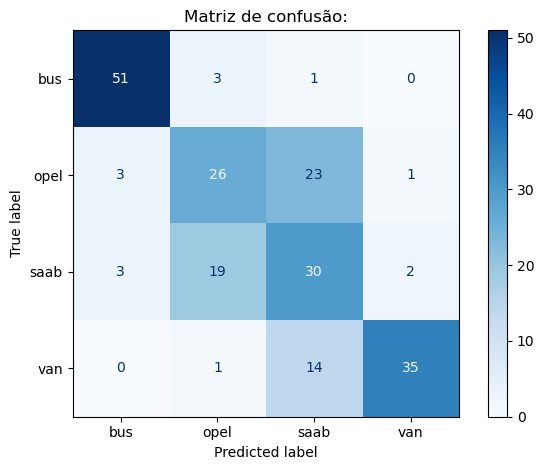

In [9]:
ConfusionMatrixDisplay.from_estimator(
    best_tree,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusão:")
plt.tight_layout()
plt.show()

## Resumo: quando usar cada técnica

| Técnica | O que resolve | Limitação |
|---|---|---|
| Holdout simples (um único `train_test_split`) | Rápido, simples | Alta variância: resultado depende de qual sorteio de teste/treino foi usado |
| K-fold / validação cruzada | Reduz a variância da estimativa de desempenho, usa todos os dados para treino e teste (em folds diferentes) | Não escolhe hiperparâmetros sozinho |
| K-fold estratificado | Além do que o k-fold resolve, preserva a proporção das classes em cada fold | Útil principalmente quando as classes são desbalanceadas |
| `GridSearchCV` (validação cruzada) | Escolhe hiperparâmetros de forma sistemática e com menos variância que o holdout | Se usado sobre *todos* os dados, a acurácia relatada (`best_score_`) ainda não veio de dados 100% independentes do processo de seleção do modelo final |

## Exercícios de fixação

1 - Realize a classificação da base `vertebralcolumn-3C` usando validação cruzada e o método grid_search para escolher os melhores hiperparâmetros dos modelos knn e árvore de decisão.

2 - Verifique se o número de folds, usado na validação cruzada, influencia na classificação da base winequality-red. Use o modelo de regressão logística.